In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Titanic dataset from the local file you just downloaded
df = pd.read_csv('titanic.csv')

# --- Exploratory Data Analysis (EDA) ---
print("--- First 5 Rows ---")
display(df.head()) 

print("\n--- Dataset Info ---")
df.info()

print("\n--- Statistical Summary ---")
display(df.describe())

print("\n--- Missing Values ---")
display(df.isnull().sum())

--- First 5 Rows ---


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 116.9 KB

--- Statistical Summary ---


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



--- Missing Values ---


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

C:\Users\KN GROUP\AppData\Local\Temp\ipykernel_6556\4173701953.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sex', y='survived', data=df, palette='pastel')
C:\Users\KN GROUP\AppData\Local\Temp\ipykernel_6556\4173701953.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='pclass', y='fare', data=df, palette='Set2')


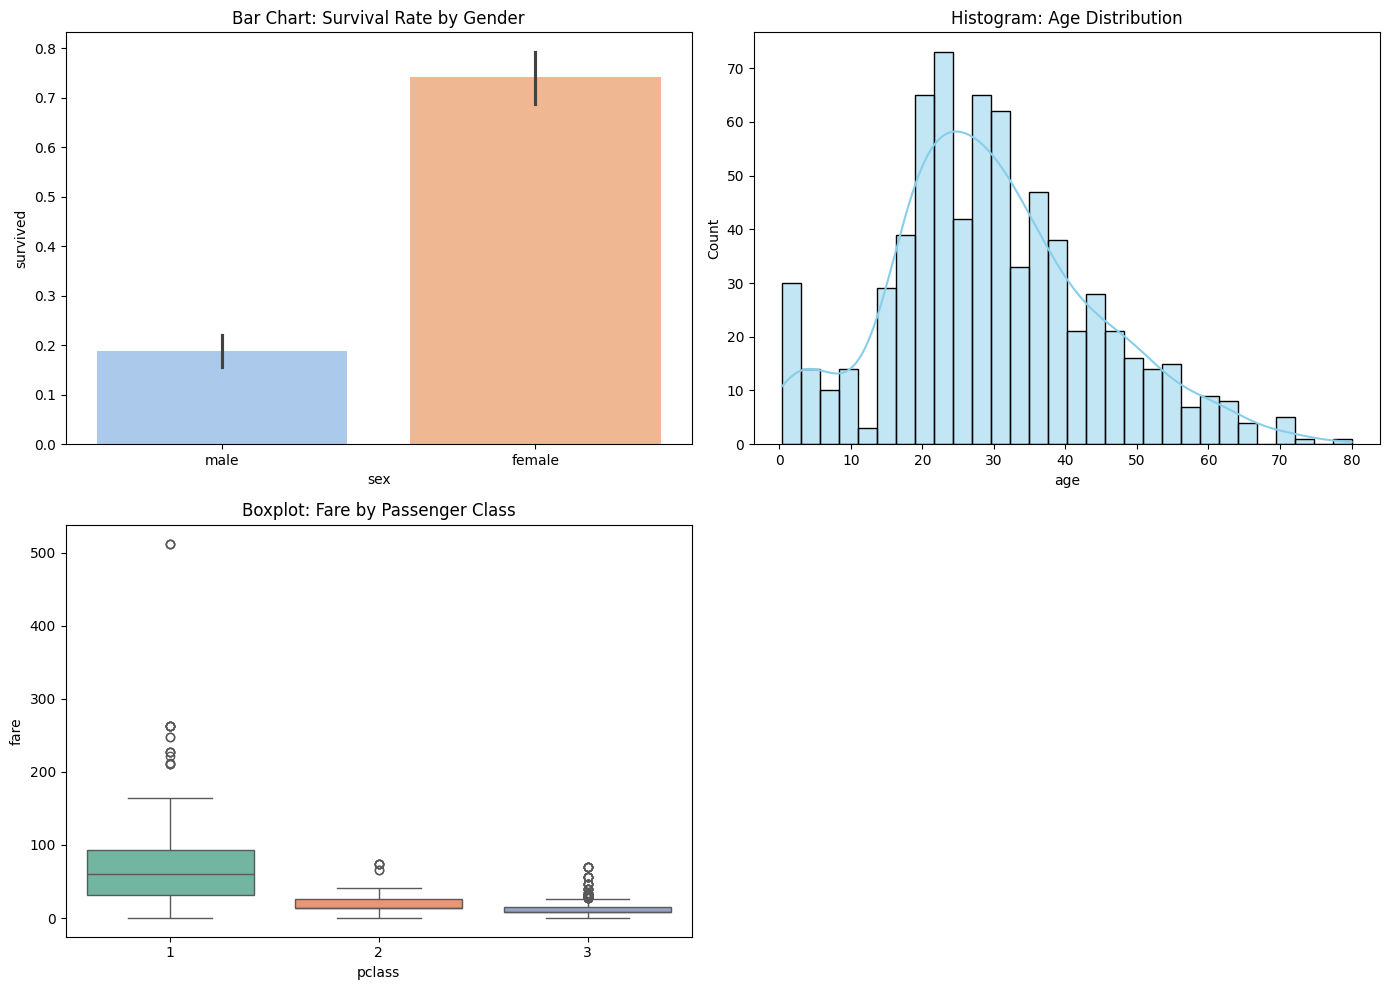


--- Pairplot ---


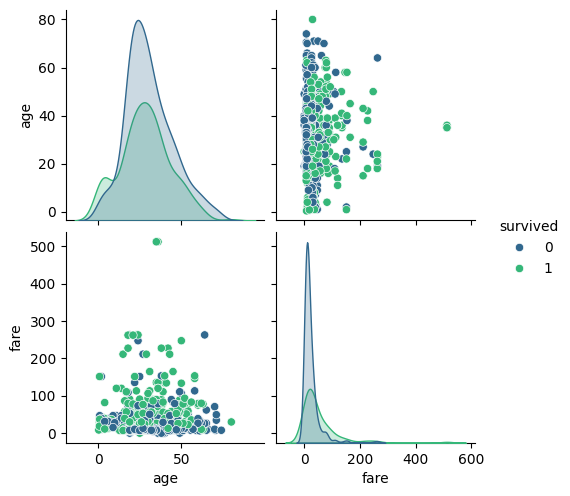

In [4]:
# --- Step 2: Data Visualization ---
plt.figure(figsize=(14, 10))

# 1. Bar Chart: Survival Rate by Gender
plt.subplot(2, 2, 1)
sns.barplot(x='sex', y='survived', data=df, palette='pastel')
plt.title('Bar Chart: Survival Rate by Gender')

# 2. Histogram: Age Distribution of Passengers
plt.subplot(2, 2, 2)
# We use dropna() here just for the plot so it doesn't crash on missing ages
sns.histplot(df['age'].dropna(), kde=True, bins=30, color='skyblue')
plt.title('Histogram: Age Distribution')

# 3. Boxplot: Fare paid by Passenger Class
plt.subplot(2, 2, 3)
sns.boxplot(x='pclass', y='fare', data=df, palette='Set2')
plt.title('Boxplot: Fare by Passenger Class')

plt.tight_layout()
plt.show()

# 4. Pairplot: Numeric features colored by Survival
print("\n--- Pairplot ---")
# Selecting a few clean numeric columns for the pairplot
subset_cols = ['age', 'fare', 'survived']
sns.pairplot(df[subset_cols].dropna(), hue='survived', palette='viridis')
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import joblib

# --- Data Preprocessing ---
# Select the specific features we want to use
features = ['pclass', 'sex', 'age', 'fare']
df_ml = df[features + ['survived']].copy()

# 1. Fill missing 'age' values with the median age of all passengers
df_ml['age'] = df_ml['age'].fillna(df_ml['age'].median())

# 2. Convert 'sex' text to numbers (male: 0, female: 1)
df_ml['sex'] = df_ml['sex'].map({'male': 0, 'female': 1})

# Drop any remaining accidental missing values just to be safe
df_ml.dropna(inplace=True)

# --- Train the Baseline Model ---

# 1. Separate features (X) and target (y)
X = df_ml.drop('survived', axis=1)
y = df_ml['survived']

# 2. Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and train the Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# 4. Make predictions
y_pred = model.predict(X_test)

# 5. Report Metrics
print("--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# --- Save the Artifact ---
joblib.dump(model, 'titanic_logistic_regression_model.pkl')
print("\nSuccess! Model saved as 'titanic_logistic_regression_model.pkl'")

--- Model Evaluation ---
Accuracy: 0.8045

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179


Success! Model saved as 'titanic_logistic_regression_model.pkl'
